# Analisis de Centros: Rotacion Septiembre 2025

Analisis exploratorio del archivo de rotacion con enfoque en los centros de trabajo.

## 1. Configuracion y Carga de Datos

In [204]:
# Importacion de librerias
import pandas as pd
import numpy as np
import unicodedata

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuracion de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Entorno configurado correctamente')

Entorno configurado correctamente


In [3]:
# Carga del dataset
df = pd.read_csv('../data/centro_completo_corte_septiembre_2025_rotación.csv')
df.columns = df.columns.str.strip().str.replace('#', 'num_').str.replace(' ', '').str.lower().str.replace('rotación', 'rotacion').str.replace('%', 'pct_')  # Eliminar espacios en blanco de los nombres de columnas
print(f'Dimensiones del dataset: {df.shape}')
print(f'\nColumnas disponibles:')
for i, col in enumerate(df.columns, 1):
    print(f'{i}. {col}')

Dimensiones del dataset: (31371, 9)

Columnas disponibles:
1. ciudad
2. num_centro
3. centro
4. num_plantamensual
5. num_bajasmensual
6. pct_rotacionmensual
7. plantapromedioam
8. num_bajasanualmovil
9. rotacionam


In [73]:
# Vista previa de los datos
print('Primeras 10 filas del dataset:')
df.sort_values(by='num_centro')

Primeras 10 filas del dataset:


,ciudad,num_centro,centro,num_plantamensual,num_bajasmensual,pct_rotacionmensual,plantapromedioam,num_bajasanualmovil,rotacionam
4376,"CD JUAREZ, CHIU",101,CDJZ 1 MUE UGARTE,16,1,0.062500,18.0,15,0.833333
4372,"CD JUAREZ, CHIU",101,NaN,16,1,0.062500,18.0,15,0.833333
14325,"CD JUAREZ, CHIU",102,CDJZ 1 ROP UGARTE,24,1,0.041667,26.0,8,0.307692
11176,"CD JUAREZ, CHIU",102,NaN,24,3,0.125000,26.0,11,0.423077
1105,"CD JUAREZ, CHIU",103,NaN,6,2,0.333333,6.0,8,1.333333
...,...,...,...,...,...,...,...,...,...
23639,"MONTERREY, N.L.",988380,NaN,1,0,0.000000,0.0,0,0.000000
24776,MIGUEL HGO D.F.,988480,NaN,1,0,0.000000,0.0,0,0.000000
29478,MIGUEL HGO D.F.,988480,NaN,1,0,0.000000,0.0,0,0.000000
30738,MIGUEL HGO D.F.,988680,NaN,1,0,0.000000,NaN,0,0.000000


In [5]:
# Informacion general del dataset
print('Informacion del dataset:')
print(df.info())
print('\n' + '='*80)
print('Estadisticas descriptivas:')
print(df.describe())

Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31371 entries, 0 to 31370
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ciudad               31371 non-null  object 
 1   num_centro           31371 non-null  int64  
 2   centro               14890 non-null  object 
 3   num_plantamensual    31371 non-null  int64  
 4   num_bajasmensual     31371 non-null  int64  
 5   pct_rotacionmensual  31371 non-null  float64
 6   plantapromedioam     31368 non-null  float64
 7   num_bajasanualmovil  31371 non-null  int64  
 8   rotacionam           31371 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.2+ MB
None

Estadisticas descriptivas:
          num_centro  num_plantamensual  num_bajasmensual  \
count   31371.000000       31371.000000      31371.000000   
mean   276844.453253           7.487616          0.316343   
std    255569.641211           8.106979

## 2. Analisis de Valores Faltantes

In [6]:
# Analisis de valores nulos
valores_nulos = df.isnull().sum()
pct_nulos = (valores_nulos / len(df)) * 100

df_nulos = pd.DataFrame({
    'Columna': valores_nulos.index,
    'Valores_Nulos': valores_nulos.values,
    'Porcentaje': pct_nulos.values
}).sort_values('Valores_Nulos', ascending=False)

print('Valores nulos por columna:')
print(df_nulos[df_nulos['Valores_Nulos'] > 0])

Valores nulos por columna:
            Columna  Valores_Nulos  Porcentaje
2            centro          16481   52.535781
6  plantapromedioam              3    0.009563


## 3. Analisis de la Variable Centro

In [7]:
# Analisis basico de centros
print('='*80)
print('ANALISIS DE CENTROS')
print('='*80)

print(f'\nTotal de registros: {len(df):,}')
print(f'Total de centros unicos: {df["num_centro"].nunique():,}')
print(f'Registros con centro sin nombre: {df["centro"].isna().sum():,}')
print(f'Registros con centro con nombre: {df["centro"].notna().sum():,}')

ANALISIS DE CENTROS

Total de registros: 31,371
Total de centros unicos: 15,751
Registros con centro sin nombre: 16,481
Registros con centro con nombre: 14,890


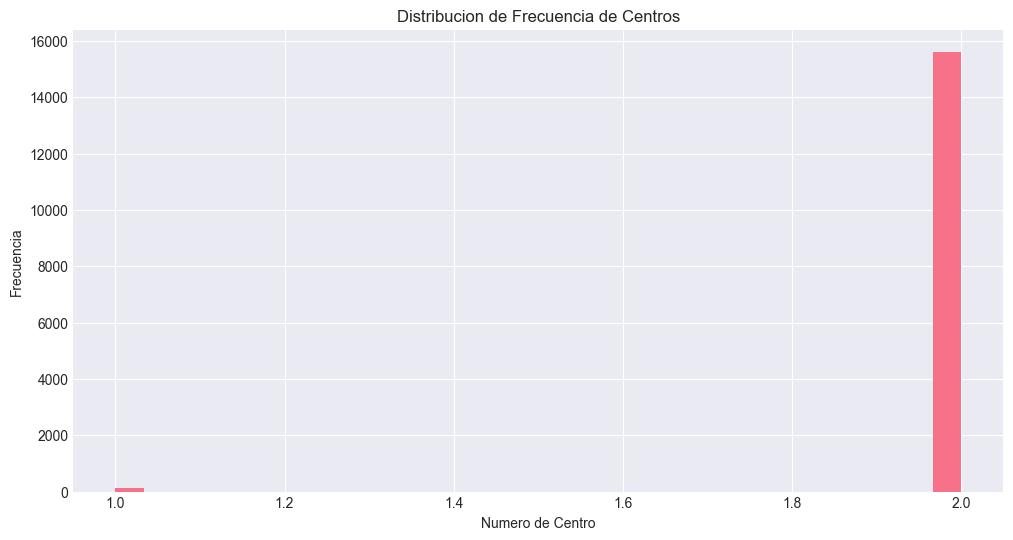

In [8]:
# Frecuencia de centros
centros_freq = df['num_centro'].value_counts().reset_index()
centros_freq.columns = ['num_centro', 'frecuencia']  # Renombrar columnas
centros_freq['frecuencia'].hist(bins=30)
plt.title('Distribucion de Frecuencia de Centros')
plt.xlabel('Numero de Centro')
plt.ylabel('Frecuencia')
plt.show()

## 3. Integracion con ```df_entrevistados_rotacion.csv```

In [218]:
df_entrevistados_rotacion = pd.read_csv('../data/df_entrevistados_rotacion.csv')
print(f'Dimensiones del dataset de entrevistados: {df_entrevistados_rotacion.shape}')

Dimensiones del dataset de entrevistados: (4670, 44)


In [220]:
df_entrevistados_rotacion.columns

Index(['num_empleado', 'escolaridad', 'numero_de_persona',
       'numero_de_trabajador', 'nombre_de_colaborador', 'tipo_rol',
       'tiene_subordinados', 'fecha_antiguedad_grupo', 'centro_de_costos',
       'centro', 'ubicacion', 'region', 'ciudad', 'empleador_legal',
       'unidad_de_negocio', 'division', 'departamento', 'codigo_de_puesto',
       'nombre_de_puesto', 'familia_de_puesto', 'funcion_del_puesto',
       'codigo_de_posicion', 'nombre_de_posicion',
       'total_plantilla_autorizada', 'total_plantilla_activa',
       'posiciones_vacantes', 'total_contrataciones_congeladas',
       'total_contrataciones_aprobadas', 'total_posiciones_presupuestadas',
       'total_indefinidos_a_cargo', 'lista_subordinados_trabajador',
       'grupos_salariales', 'lista_centros_subordinados',
       'promedio_grupo_salarial', 'std_grupo_salarial', 'moda_grupo_salarial',
       'promedio_antiguedad_subordinados_anos', 'std_antiguedad_equipo',
       'antiguedad_anois', 'numero_centros_a_carg

In [221]:
df_entrevistados_rotacion.rename(columns={'numero_centros_a_cargo': 'centros_de_adscripción_subordinados'}, inplace=True)

<Axes: >

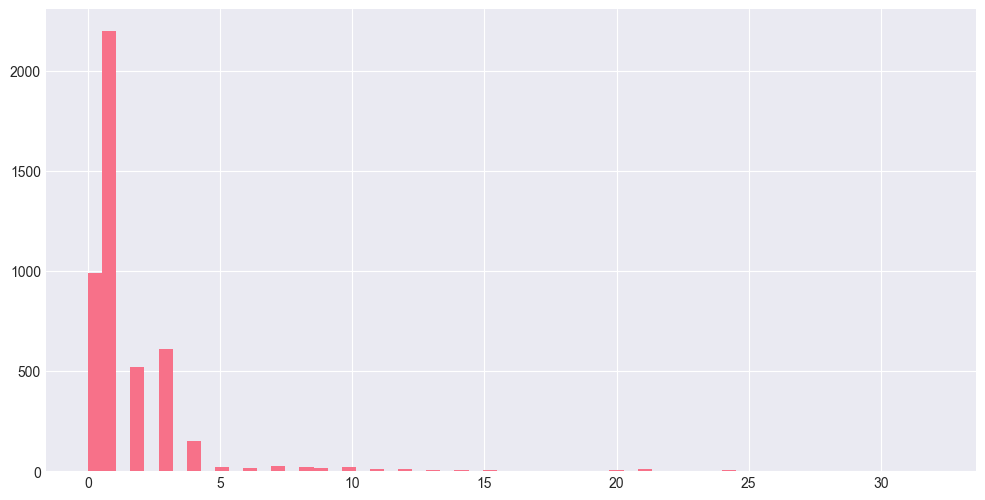

In [223]:
df_entrevistados_rotacion['centros_de_adscripción_subordinados'].hist(bins=60)

In [228]:
import ast

df_rotacion = pd.DataFrame(columns=[ 'numero_de_persona', 'planta_mensual_multicentro',
    'bajas_mensual_multicentro', 'rotacion_mensual_pct_multicentro', 'planta_promedio_anual_movil_multicentro',
    'bajas_anuales_moviles_multicentro', 'rotacion_anual_movil_pct_multicentro'])

for gerente in df_entrevistados_rotacion['num_empleado'].unique():
    try:
        lista_centro_cargo = ast.literal_eval(df_entrevistados_rotacion[df_entrevistados_rotacion['num_empleado'] == gerente]['lista_centros_subordinados'].values[0])
        print(f'Gerente: {gerente} - Centros a cargo: {lista_centro_cargo}')
        lista_num_centro = []
        lista_nombres_centros = []
        lista_num_platamensual = []
        lista_num_bajasmensual = []
        lista_pct_rotacionmensual = []
        lista_plantapromedioam = []
        lista_num_bajasanualmovil = []
        lista_rotacionam = []

        for numero_centro in lista_centro_cargo:    
            df_values = df[(df['num_centro'] == numero_centro) & ( ~ df['centro'].isna())]
            if df_values.empty:
                print(f'    Centro {numero_centro} no encontrado o sin nombre, se omite.')
                continue
            else:
                lista_num_centro.append(numero_centro)
                for col in ['num_centro', 'centro', 'num_plantamensual', 'num_bajasmensual', 'pct_rotacionmensual', 'plantapromedioam', 'num_bajasanualmovil', 'rotacionam']:
                    valor_unico = df_values[col].values[0]
                    
                    if col == 'centro':
                        lista_nombres_centros.append(valor_unico)
                    elif col == 'num_centro':
                        lista_num_centro.append(valor_unico)
                    elif col == 'num_plantamensual':
                        lista_num_platamensual.append(valor_unico)
                    elif col == 'num_bajasmensual':
                        lista_num_bajasmensual.append(valor_unico)
                    elif col == 'pct_rotacionmensual':
                        lista_pct_rotacionmensual.append(valor_unico)
                    elif col == 'plantapromedioam':
                        lista_plantapromedioam.append(valor_unico)
                    elif col == 'num_bajasanualmovil':
                        lista_num_bajasanualmovil.append(valor_unico)
                    elif col == 'rotacionam':
                        lista_rotacionam.append(valor_unico)
        data = {
            'numero_de_persona': gerente,
            'planta_mensual_multicentro': sum(lista_num_platamensual) if len(lista_num_platamensual) > 0 else 0,
            'bajas_mensual_multicentro': sum(lista_num_bajasmensual) if len(lista_num_bajasmensual) > 0 else 0,
            'rotacion_mensual_pct_multicentro': sum(lista_pct_rotacionmensual) / len(lista_pct_rotacionmensual) if len(lista_pct_rotacionmensual) > 0 else 0,
            'planta_promedio_anual_movil_multicentro': sum(lista_plantapromedioam)  if len(lista_plantapromedioam) > 0 else 0,
            'bajas_anuales_moviles_multicentro': sum(lista_num_bajasanualmovil) if len(lista_num_bajasanualmovil) > 0 else 0,
            'rotacion_anual_movil_pct_multicentro': sum(lista_rotacionam) / len(lista_rotacionam) if len(lista_rotacionam) > 0 else 0
        }
        df_nuevo_row = pd.DataFrame([data])
    except Exception as e:
        print(f'Error al procesar gerente {gerente}: {e}')
    
    df_rotacion = pd.concat([df_rotacion, df_nuevo_row], ignore_index=True)

Gerente: 90097812 - Centros a cargo: [503101]
Gerente: 92650554 - Centros a cargo: [785701]
Gerente: 92109391 - Centros a cargo: [501102]
Gerente: 90391277 - Centros a cargo: [546501]
Gerente: 90269515 - Centros a cargo: [117102]
Gerente: 94566526 - Centros a cargo: [662001]
Gerente: 94296791 - Centros a cargo: [763602, 763603]
Gerente: 98427873 - Centros a cargo: [773203, 773280, 773290]
Gerente: 91711592 - Centros a cargo: [106602]
Gerente: 90736729 - Centros a cargo: [511701]
Gerente: 97214345 - Centros a cargo: [902]
Gerente: 97663255 - Centros a cargo: [532501]
Gerente: 93552361 - Centros a cargo: [520401]
Gerente: 97104833 - Centros a cargo: [74601]
Gerente: 91137195 - Centros a cargo: [799501]
Gerente: 90166188 - Centros a cargo: [62002, 62003]
Gerente: 98495062 - Centros a cargo: [761502]
Gerente: 98490851 - Centros a cargo: [113601]
Gerente: 98461451 - Centros a cargo: [501801]
Gerente: 90239066 - Centros a cargo: [666001]
Gerente: 93601662 - Centros a cargo: [534801]
Gerente:

In [229]:
df_rotacion[df_rotacion['numero_de_persona'] == 95092668]

,numero_de_persona,planta_mensual_multicentro,bajas_mensual_multicentro,rotacion_mensual_pct_multicentro,planta_promedio_anual_movil_multicentro,bajas_anuales_moviles_multicentro,rotacion_anual_movil_pct_multicentro
1468,95092668,250,9,0.028438,255.0,102,0.344513


In [232]:
df_rotacion.drop_duplicates(subset=['numero_de_persona'], keep='first', inplace=True)
print(f'Dimensiones del dataset de rotacion por multicentro: {df_rotacion.shape}')

Dimensiones del dataset de rotacion por multicentro: (3682, 7)


In [233]:
df_resultado = df_entrevistados_rotacion.merge(df_rotacion, on='numero_de_persona', how='left')
print(f'Dimensiones del dataset resultado: {df_resultado.shape}')

Dimensiones del dataset resultado: (4670, 50)


In [244]:
df_resultado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4670 entries, 0 to 4669
Data columns (total 50 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   num_empleado                             4670 non-null   int64  
 1   escolaridad                              4670 non-null   object 
 2   numero_de_persona                        4670 non-null   object 
 3   numero_de_trabajador                     4670 non-null   int64  
 4   nombre_de_colaborador                    4670 non-null   object 
 5   tipo_rol                                 4670 non-null   object 
 6   tiene_subordinados                       4670 non-null   bool   
 7   fecha_antiguedad_grupo                   4670 non-null   object 
 8   centro_de_costos                         4670 non-null   object 
 9   centro                                   4670 non-null   int64  
 10  ubicacion                                4670 no

In [ ]:
# ----------------------------------------------------------------------
# 1. Identificación y Datos Personales del Colaborador
# ----------------------------------------------------------------------
variables_rrhh_identificacion = [
    'num_empleado',              # Número único de identificación del empleado.
    'escolaridad',               # Nivel de estudios del colaborador.
    'numero_de_persona',         # Identificador de persona.
    'numero_de_trabajador',      # Otro identificador de trabajador.
    'nombre_de_colaborador',     # Nombre completo del colaborador.
    'antiguedad_anois',          # Antigüedad del colaborador en años.
]

# ----------------------------------------------------------------------
# 2. Información del Puesto y Rol del manager
# ----------------------------------------------------------------------
variables_rrhh_puesto_rol = [
    'tipo_rol',                  # Tipo de rol que desempeña (e.g., manager, individual contributor).
    'codigo_de_puesto',          # Código único que identifica el puesto.
    'nombre_de_puesto',          # Nombre descriptivo del puesto.
    'familia_de_puesto',         # Categoría de puestos con funciones similares.
    'funcion_del_puesto',        # Descripción de la función principal del puesto.
    'codigo_de_posicion',        # Código único de la posición específica.
    'nombre_de_posicion',        # Nombre de la posición específica.
]

# ----------------------------------------------------------------------
# 3. Estructura Organizacional y Ubicación del manager
# ----------------------------------------------------------------------
variables_rrhh_organizacion_ubicacion = [
    'centro_de_costos',          # Centro de costos asignado.
    'centro',                    # Centro de trabajo.
    'ubicacion',                 # Ubicación física de trabajo.
    'region',                    # Región geográfica.
    'ciudad',                    # Ciudad de la ubicación.
    'empleador_legal',           # Entidad legal que contrata.
    'unidad_de_negocio',         # Área o división principal.
    'division',                  # Subdivisión de la unidad de negocio.
    'departamento',              # Departamento o área específica.
    'centros_de_adscripción_subordinados', # Centros de trabajo asociados a los subordinados.
]

# ----------------------------------------------------------------------
# 4. Antigüedad y Tiempo subordinados
# ----------------------------------------------------------------------
variables_rrhh_antiguedad = [
    'fecha_antiguedad_grupo',    # Fecha de inicio de antigüedad en el grupo/empresa.
    'promedio_antiguedad_subordinados_anos', # Promedio de antigüedad del equipo a cargo.
    'std_antiguedad_equipo',     # Desviación estándar de la antigüedad del equipo.
]

# ----------------------------------------------------------------------
# 5. Gestión de Personal, Equipo y Liderazgo
# ----------------------------------------------------------------------
variables_rrhh_gestion_equipo = [
    'tiene_subordinados',        # Indicador de si el colaborador tiene personal a cargo (Booleano).
    'lista_subordinados_trabajador', # Lista de IDs de los subordinados directos.
    'lista_centros_subordinados',# Lista de centros de costos de los subordinados.
    'total_indefinidos_a_cargo', # Número de empleados indefinidos a su cargo.
    'tamano_equipo',             # Número total de personas en el equipo (subordinados).
]

# ----------------------------------------------------------------------
# 6. Variables Salariales y Compensación de subordinados
# ----------------------------------------------------------------------
variables_rrhh_salariales = [
    'grupos_salariales',         # Grupo salarial del colaborador.
    'promedio_grupo_salarial',   # Promedio del grupo salarial del equipo a cargo.
    'std_grupo_salarial',        # Desviación estándar del grupo salarial del equipo.
    'moda_grupo_salarial',       # Grupo salarial más frecuente en el equipo.
]

# ----------------------------------------------------------------------
# 7. Planificación y Presupuesto de Plantilla
# ----------------------------------------------------------------------
variables_rrhh_planificacion_plantilla = [
    'total_plantilla_autorizada',# Número máximo de empleados permitido.
    'total_plantilla_activa',    # Número de empleados actualmente contratados.
    'total_posiciones_presupuestadas', # Posiciones consideradas en el presupuesto.
    'posiciones_vacantes',       # Posiciones autorizadas sin cubrir.
    'posiciones_vacantes_activas', # Posiciones vacantes en proceso de reclutamiento.
    'total_contrataciones_congeladas', # Contrataciones suspendidas.
    'total_contrataciones_aprobadas', # Contrataciones que han recibido aprobación.
    'indice_rigidez_contratacion', # Métrica de la restricción para contratar.
    'pct_posiciones_vacantes',   # Porcentaje de posiciones vacantes sobre el total.
]

# ----------------------------------------------------------------------
# 8. Métricas de Rotación y Movimiento de Personal (Multicentro)
# ----------------------------------------------------------------------
variables_rrhh_metricas_rotacion = [
    'planta_mensual_multicentro', # Número promedio de empleados en el mes (multicentro).
    'bajas_mensual_multicentro',  # Número de salidas/bajas en el mes (multicentro).
    'rotacion_mensual_pct_multicentro', # Tasa de rotación mensual (porcentaje) (multicentro).
    'planta_promedio_anual_movil_multicentro', # Promedio de empleados en los últimos 12 meses (multicentro).
    'bajas_anuales_moviles_multicentro', # Total de salidas/bajas en los últimos 12 meses (multicentro).
    'rotacion_anual_movil_pct_multicentro', # Tasa de rotación anual móvil (porcentaje) (multicentro).
]


In [258]:
df_resultado[['num_empleado',
 'nombre_de_puesto',
 'antiguedad_anois',
 'nombre_de_posicion',
 'promedio_grupo_salarial',
 'promedio_antiguedad_subordinados_anos',
 'indice_rigidez_contratacion',
 'pct_posiciones_vacantes',
 'tamano_equipo',
 'total_plantilla_activa',
 'planta_mensual_multicentro',
 'posiciones_vacantes_activas',
 'centros_de_adscripción_subordinados',
 'bajas_mensual_multicentro',
 'rotacion_mensual_pct_multicentro',
 'planta_promedio_anual_movil_multicentro',
 'bajas_anuales_moviles_multicentro',
'rotacion_anual_movil_pct_multicentro']].sort_values('centros_de_adscripción_subordinados', ascending=False).head(10)

,num_empleado,nombre_de_puesto,antiguedad_anois,nombre_de_posicion,promedio_grupo_salarial,promedio_antiguedad_subordinados_anos,indice_rigidez_contratacion,pct_posiciones_vacantes,tamano_equipo,total_plantilla_activa,planta_mensual_multicentro,posiciones_vacantes_activas,centros_de_adscripción_subordinados,bajas_mensual_multicentro,rotacion_mensual_pct_multicentro,planta_promedio_anual_movil_multicentro,bajas_anuales_moviles_multicentro,rotacion_anual_movil_pct_multicentro
4566,92459511,GERENTE DE ZONA TIENDA,17.932923,GERENTE DE ZONA TIENDA,7.042254,6.258151,0.705882,19.148936,47,38,193,9,32,9,0.024854,205.0,95,0.397763
2105,93626401,GERENTE DE ZONA TIENDA,8.969199,GERENTE DE ZONA TIENDA,7.903226,5.716632,0.608696,16.666667,48,40,203,8,30,5,0.029258,208.0,55,0.207854
2878,91201713,GERENTE DE ZONA TIENDA,21.478439,GERENTE DE ZONA TIENDA,7.774194,11.796095,0.347826,25.925926,54,40,158,14,30,11,0.034342,168.0,53,0.255523
1468,95092668,GERENTE DE ZONA TIENDA,13.169062,GERENTE DE ZONA TIENDA,7.952381,9.057675,0.730769,13.636364,44,38,250,6,29,9,0.028438,255.0,102,0.344513
3539,91463599,GERENTE DE ZONA TIENDA,20.585900,GERENTE DE ZONA TIENDA,7.827586,6.582840,0.880000,5.555556,36,34,176,2,27,13,0.047787,186.0,109,0.412338
2248,92373364,GERENTE DE ZONA TIENDA,18.023272,GERENTE DE ZONA TIENDA,8.819672,10.024596,0.322581,39.215686,51,31,141,20,26,6,0.020316,153.0,57,0.306435
2679,92175422,GERENTE DE ZONA TIENDA,18.132786,GERENTE DE ZONA TIENDA,7.300000,8.290603,0.500000,32.692308,52,35,124,17,26,7,0.032035,132.0,50,0.225223
4552,90284895,GERENTE DE ZONA TIENDA,27.723477,GERENTE DE ZONA TIENDA,7.250000,6.939995,0.370370,34.782609,46,30,157,16,25,13,0.050603,167.0,115,0.513434
3940,93983913,GERENTE DE ZONA TIENDA,15.288159,GERENTE DE ZONA TIENDA,7.833333,5.823055,0.750000,13.888889,36,31,178,5,24,11,0.044473,188.0,64,0.272344
3914,95173201,GERENTE DE ZONA SERVICIOS FINANCIEROS,13.034908,GERENTE DE ZONA SERVICIOS FINANCIEROS,7.512195,5.672080,0.000000,73.170732,41,11,144,30,24,8,0.048753,151.0,104,0.566661


In [248]:
df_resultado.to_csv('../data/df_analisis_rotacion_multicentro.csv', index=False)

## Experimentos

In [205]:
# Extraer el número del grado (ej. 'GLOBAL GRADE 05' -> 5)
def extraer_grado_numerico(grado):
    if pd.isna(grado):
        return None
    # Usa una expresión regular para encontrar el primer conjunto de dígitos
    match = re.search(r'(\d+)', str(grado))
    if match:
        return int(match.group(1))
    return None # Retorna None si no se encuentra un número

def limpiar_nombre_columna(texto):
    """Función para limpiar nombres de columnas"""
    # Remover acentos
    texto = unicodedata.normalize('NFD', str(texto))
    texto = ''.join(char for char in texto if unicodedata.category(char) != 'Mn')
    
    # Reemplazar espacios y caracteres especiales con guión bajo
    texto = texto.replace(' ', '_')
    texto = texto.replace('-', '_')
    texto = texto.replace(',', '')
    texto = texto.replace('(', '')
    texto = texto.replace(')', '')
    
    # Convertir a minúsculas
    texto = texto.lower()
    
    # Limpiar guiones bajos múltiples
    while '__' in texto:
        texto = texto.replace('__', '_')
    
    # Remover guión bajo al inicio/final
    texto = texto.strip('_')
    
    return texto

def reemplazar_pd_na_con_nan(df):
    """Reemplaza todos los pd.NA con np.nan"""
    df_limpio = df.copy()
    
    # Reemplazar pd.NA con np.nan en todo el DataFrame
    df_limpio = df_limpio.replace({pd.NA: np.nan})
    
    return df_limpio


# Convertir columnas específicas
def convertir_columnas_especificas(df, columnas):
    """Convierte columnas específicas a entero"""
    
    for col in columnas:
        if col in df.columns:
            try:
                # Convertir a numérico y luego a entero
                df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
                print(f"[+] Convertido: {col}")
                
            except Exception as e:
                print(f"[-] Error en {col}: {e}")
    
    return df

In [206]:
# Cargar dataset de plantilla
df_plantilla = pd.read_csv('../data/GCP_Core_Plantilla_ActivaVSAutorizada_REP_8_Sheet1.csv', 
                           low_memory=False)
df_plantilla = df_plantilla.iloc[:, :-4]
df_plantilla.columns = df_plantilla.columns.str.strip()  # Eliminar espacios
df_plantilla.columns = [limpiar_nombre_columna(col) for col in df_plantilla.columns]
# Aplicar conversión
columnas_enteras = [
    'centro',
    'codigo_de_puesto',
    'codigo_de_posicion',
    'codigo_de_posicion_principal',
    'plantilla_autorizada',
    'plantilla_activa',
    'vacantes',
    'numero_trabajador',
    'numero_de_persona', 
    'numero_de_trabajador', 
    'numero_de_persona_del_manager',	
    'numero_de_trabajador_del_manage'
]
df_platilla = convertir_columnas_especificas(df_plantilla, columnas_enteras)
df_plantilla = reemplazar_pd_na_con_nan(df_plantilla)

[+] Convertido: centro
[+] Convertido: codigo_de_puesto
[+] Convertido: codigo_de_posicion
[+] Convertido: codigo_de_posicion_principal
[+] Convertido: plantilla_autorizada
[+] Convertido: plantilla_activa
[+] Convertido: vacantes
[+] Convertido: numero_de_persona
[+] Convertido: numero_de_trabajador
[+] Convertido: numero_de_persona_del_manager


In [208]:
df_agg = df_plantilla[['centro', 'numero_de_persona']][df_plantilla['numero_de_persona'].notna()].groupby('centro').agg({'count'}).reset_index()
df_agg.columns = ['centro', 'total_numero_de_persona']
df_agg.head()



,centro,total_numero_de_persona
0,101,16
1,102,25
2,103,6
3,110,2
4,180,14


In [212]:
df_test.merge(df_agg, left_on='num_centro', right_on='centro', how='inner')

,ciudad,num_centro,centro_x,num_plantamensual,num_bajasmensual,pct_rotacionmensual,plantapromedioam,num_bajasanualmovil,rotacionam,centro_y,total_numero_de_persona
0,IZTAPALAPA D.F.,31001,IZTP 310 MUE SANTA MARTHA,15,0,0.000000,14.0,6,0.428571,31001,15
1,IZTAPALAPA D.F.,31002,IZTP 310 ROP SANTA MARTHA,12,1,0.083333,12.0,15,1.250000,31002,12
2,IZTAPALAPA D.F.,31010,IZTP 310 GTE SANTA MARTHA,1,0,0.000000,2.0,1,0.500000,31010,1
3,IZTAPALAPA D.F.,31080,IZTP 310 BAN SANTA MARTHA,15,1,0.066667,14.0,7,0.500000,31080,15
4,IZTAPALAPA D.F.,33201,IZTP 332 MUE PURISIMA,14,0,0.000000,14.0,4,0.285714,33201,16
5,IZTAPALAPA D.F.,33202,IZTP 332 ROP PURISIMA,12,1,0.083333,15.0,9,0.600000,33202,15
6,IZTAPALAPA D.F.,33210,IZTP 332 GTE PURISIMA,1,0,0.000000,1.0,0,0.000000,33210,1
7,IZTACALCO D.F,41010,IZTC 410 GTE SUR 16,1,0,0.000000,1.0,0,0.000000,41010,1
8,IZTAPALAPA D.F.,45501,IZTP 455 MUE ERMITA IZTAPALAPA,21,2,0.095238,22.0,3,0.136364,45501,20
9,IZTAPALAPA D.F.,45502,IZTP 455 ROP ERMITA IZTAPALAPA,29,1,0.034483,29.0,20,0.689655,45502,29


In [215]:
df_plantilla[df_plantilla['centro'].isin(lista)][df_plantilla['numero_de_persona'].notna()].groupby('centro').agg({'count'}).reset_index()

,centro,fecha_de_inicio_de_vigencia,fecha_de_cierre,estado,estado_contratacion,posicion_presupuestada,importe,centro_de_costos,ubicacion,region,...,nombre_del_colaborador,fecha_de_antiguedad_grupo,fecha_de_contratacion_empleador_legal_actual,fecha_de_entrada_en_posicion_actual,tipo_de_trabajador,codigo_de_posicion_principal,nombre_de_posicion_principal,numero_de_persona_del_manager,numero_de_trabajador_del_manager,nombre_del_manager
,,count,count,count,count,count,count,count,count,count,...,count,count,count,count,count,count,count,count,count,count
0,31001,15,0,15,15,15,15,15,15,15,...,15,15,15,15,15,15,15,15,15,15
1,31002,12,1,12,12,12,12,12,12,12,...,12,12,12,12,12,12,12,12,12,12
2,31010,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3,31080,15,0,15,15,15,15,15,15,15,...,15,15,15,15,15,15,15,15,15,15
4,33201,16,2,16,16,16,16,16,16,16,...,16,16,16,16,16,16,16,16,16,16
5,33202,15,3,15,15,15,15,15,15,15,...,15,15,15,15,15,15,15,15,15,15
6,33210,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
7,41010,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
8,45501,20,0,20,20,20,20,20,20,20,...,20,20,20,20,20,20,20,20,20,20
